# Init

In [ ]:
import sympy  as sp

# Symxplorer Specific Imports
from   symxplorer.symbolic_exploration.domains   import ExperimentResult
from   symxplorer.designer_tools.visualizer      import Symbolic_Visualizer, Bode_Visualizer
from   symxplorer.designer_tools.symbolic_sizing import Symbolic_Sizing_Assist

s = sp.symbols("s")

# Load the exploration result

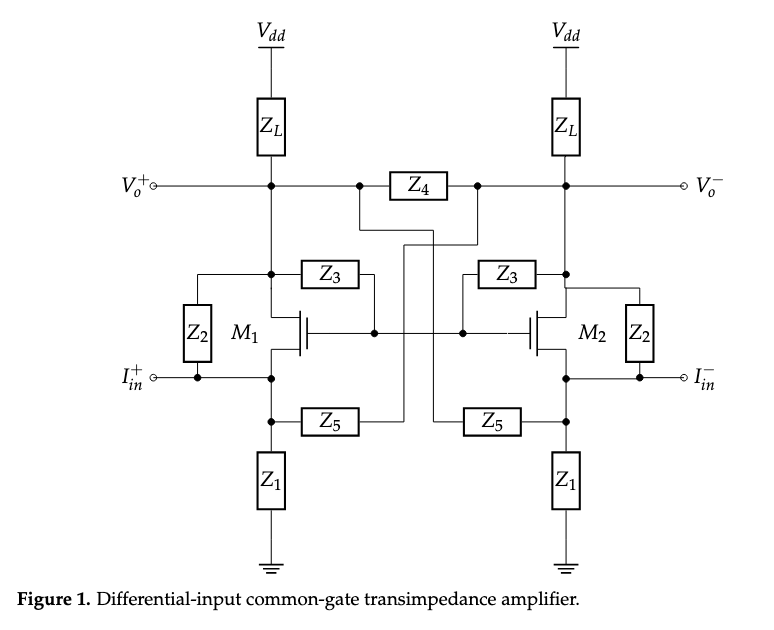

In [6]:
experiment_name = "CG_TIA_Automated_simple"
path_to_pkl = f"Runs/{experiment_name}/results.pkl"
symbolic_experiment_result = ExperimentResult(experiment_name=experiment_name)
symbolic_experiment_result = symbolic_experiment_result.load(path_to_pkl)

# Problem Setup

## Select a topology to size

In [7]:
ALLOWED_Z_CONNECTIONS = "Z1_Z2_ZL"
classifications, tf = symbolic_experiment_result.get_impedance_key(ALLOWED_Z_CONNECTIONS)
print(f"{ALLOWED_Z_CONNECTIONS} - count of tfs {len(classifications)}")
tf

Z1_Z2_ZL - count of tfs 880


(Z_1*Z_2*Z_L*g_m + Z_1*Z_L)/(Z_1*Z_2*g_m + Z_1 + Z_2 + Z_L)

In [8]:
FILTER_TYPE = "BP" # should switch to using enums
classifications_filtered = symbolic_experiment_result.get_filter_types(fTypes=[FILTER_TYPE], zCombos=ALLOWED_Z_CONNECTIONS)
len(classifications_filtered)

6

In [9]:
sel = 4
tf_to_size = classifications_filtered[sel]
print(f"Selected Z-combo is\n{tf_to_size.zCombo}")
print(f"numer order = {tf_to_size.tf_numer_order}\ndenom_order = {tf_to_size.tf_denom_order}\nfilter_id: {tf_to_size.filter_id}")
tf_to_size.transferFunc

Selected Z-combo is
(L_1*s/(C_1*L_1*s**2 + 1), R_2, oo, oo, oo, R_L)
numer order = 1
denom_order = 2
filter_id: 3120


s*(L_1*R_2*R_L*g_m + L_1*R_L)/(R_2 + R_L + s**2*(C_1*L_1*R_2 + C_1*L_1*R_L) + s*(L_1*R_2*g_m + L_1))

### Filter Parameters

In [10]:
print(f"filter parameters are {tf_to_size.parameters.keys()}")

filter parameters are dict_keys(['Q', 'wo', 'bandwidth', 'K_LP', 'K_HP', 'K_BP', 'Qz', 'Wz'])


In [11]:
# Q
tf_to_size.parameters.get("Q", None)

(sqrt(C_1)*R_2 + sqrt(C_1)*R_L)/(sqrt(L_1)*R_2*g_m + sqrt(L_1))

In [12]:
# WO
tf_to_size.parameters.get("wo", None)

1/(sqrt(C_1)*sqrt(L_1))

In [13]:
# bandwidth
tf_to_size.parameters.get("bandwidth", None)

(sqrt(L_1)*R_2*g_m + sqrt(L_1))/(sqrt(C_1)*sqrt(L_1)*(sqrt(C_1)*R_2 + sqrt(C_1)*R_L))

In [14]:
# K_BP
tf_to_size.parameters.get("K_BP", None)

R_L

# Design Space Exploration of the Selected Topology

In [15]:
assist = Symbolic_Sizing_Assist(
    filter_classification=tf_to_size
)

In [16]:
assist.get_design_variables()

['R_L', 'C_1', 'L_1', 'g_m', 'R_2']

In [17]:
assist.get_metrics()

['Q', 'wo', 'bandwidth', 'K_BP']

In [18]:
# assist.kill_variable()

In [25]:

# 'R_1', 'g_m', 'R_2', 'C_L', 'L_L', 'R_L'
exploration = assist.explore_systematically(design_var_limits={
    # "R_1" : (0.1e3, 100e3),
    "R_2" : (0.1e3, 100e3),
    "R_L" : (0.1e3, 100e3),    
    # "g_m" : (1e-3, 100e-3),    
    # "C_1" : (10e-15, 10e-12),    
    # "L_L" : (1e-12, 1e-9),    
}, 
num_points_per_var=25,
fixed_vars={
    "g_m" : 1e-2,
    "C_1" : 1e-12,
    "L_1" : 1e-9
})

Exploring design space: 100%|█████████████████| 625/625 [00:23<00:00, 26.41it/s]


In [26]:
from symxplorer.designer_tools.visualizer import AnalysisSuite

analysis = AnalysisSuite(exploration=exploration)

In [29]:
analysis.plot_contour(x_param="x_R_L", y_param="x_R_2", metric_name="K_BP")

In [30]:
analysis.plot_sensitivity(metric_name="wo")

In [32]:
analysis.plot_tradeoff(metric1="Q", metric2="K_BP")

In [35]:
analysis.plot_box(design_var="x_R_L", metric_name="K_BP")

In [37]:
analysis.plot_distribution(metric_name="K_BP")

In [38]:
analysis.plot_3d_scatter(design_var1="x_R_L", design_var2="x_R_2", metric_name="K_BP")

In [39]:
analysis.plot_progression(metric_name="K_BP")

In [43]:
analysis.plot_parallel(metrics=["wo"])

# Visualizing the Frequency Response

In [ ]:
sym_vis = Symbolic_Visualizer(filter_classification=tf_to_size)
sym_vis.is_defined_numerically()

In [ ]:
sym_vis.get_parameters()

In [ ]:
sym_vis.set_params(param_str_to_value={
    "R" : 1e3, # used in case of equal R
    "C" : 1e-12, # used in case of equal C
    "R_1" : 1e3,
    "R_2" : 1e3,
    "C_L" : 100e-12,
    "L_L" : 1e-9,
    "g_m" : 20e-3,
})
sym_vis.params_to_value

In [ ]:
magnitude_expr, phase_expr, H_numeric = sym_vis.get_bode_expression()
H_numeric

In [ ]:
expr, val = sym_vis.eval_filter_parameter(param_name="K_BP", num_of_decimals=3)
expr

In [ ]:
sym_vis.print_filter_parameters()
sym_vis.visualize(start_freq_order=8.4, end_freq_order=8.8, num_of_points=200)